# EMRI Tidal Heating GW Strain 

/Users/leifl/anaconda3/envs/emri_env/lib/python3.9/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/leifl/anaconda3/envs/emri_env/lib/python3.9/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


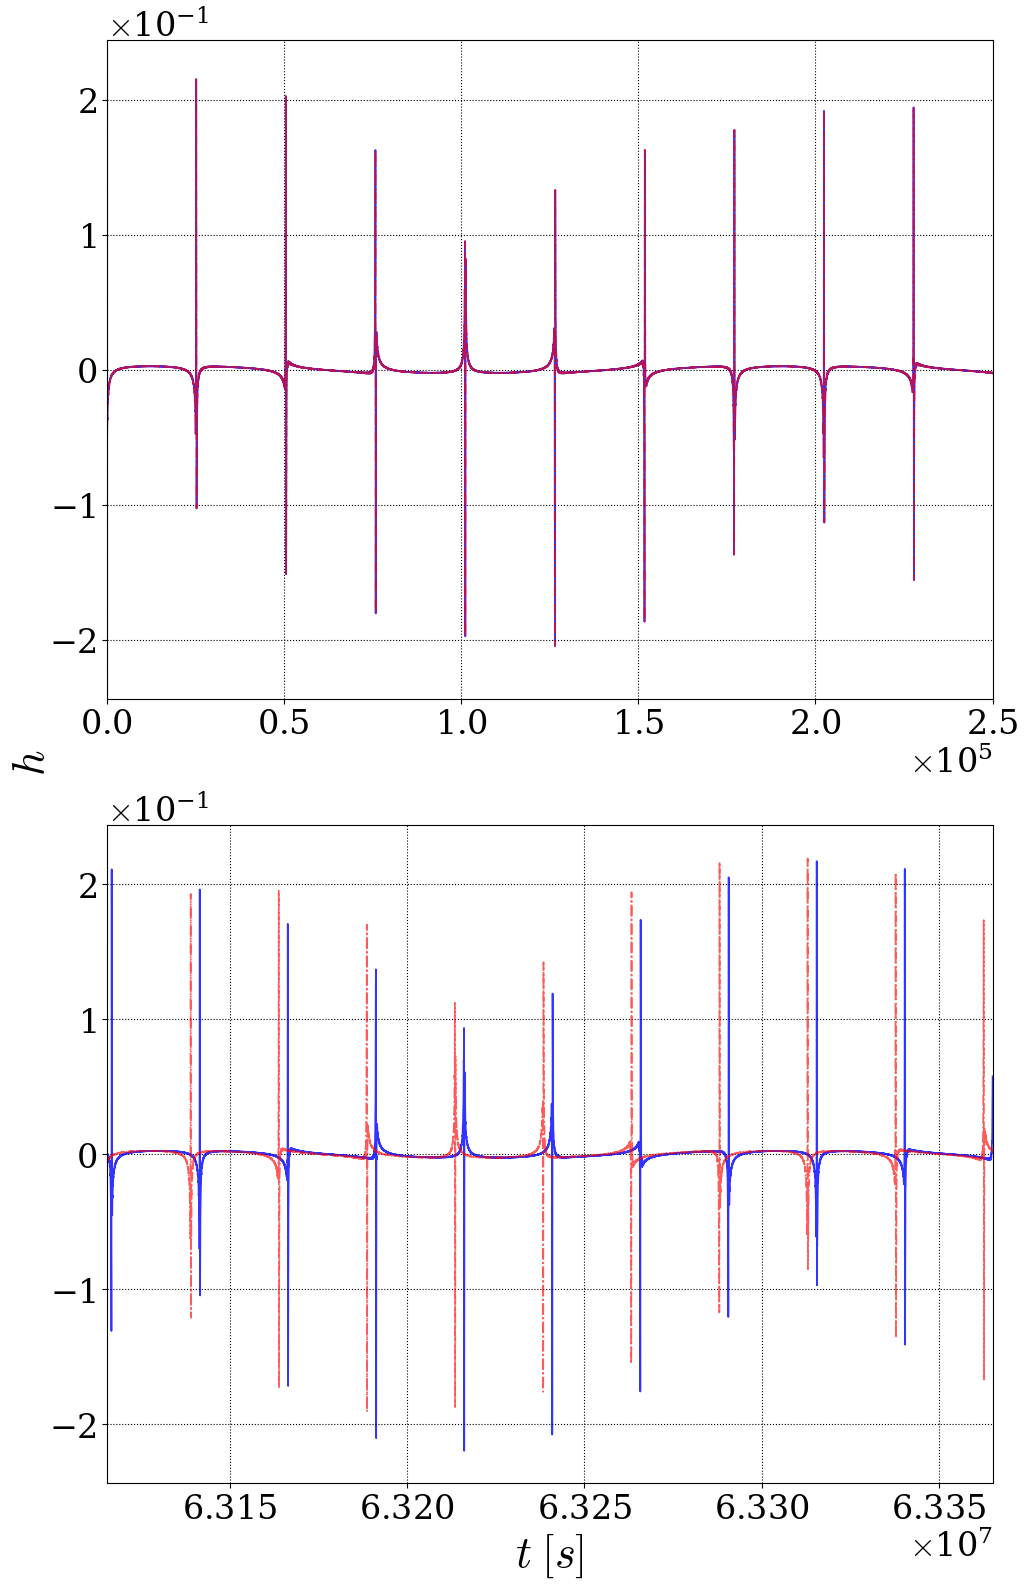

In [2]:

h = np.load('EMRI_TH_GW_Waveform_M_1e5_mu_6e-1_p_30_4yrs.npz',allow_pickle=True)
h_GW = h['h_GW']
h_TH = h['h_TH']
Tgrid_dense = h['tGW_ht']

#Create interpolants
h_GW_interp = interp1d(Tgrid_dense, h_GW, kind='cubic', fill_value='extrapolate')
h_TH_interp = interp1d(Tgrid_dense, h_TH, kind='cubic', fill_value='extrapolate')

Tgrid_dense = np.arange(0, Tgrid_dense[-1], 5)

h_GW = h_GW_interp(Tgrid_dense)
h_TH = h_TH_interp(Tgrid_dense)



plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.rm'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'  # Computer Modern look-alike
plt.rcParams['font.family'] = 'serif'
plt.rc('xtick', labelsize=24)   # fontsize of the tick labels
plt.rc('ytick', labelsize=24)   # fontsize of the tick labels

fig = plt.figure(figsize=(10, 16))
ax1 = fig.add_subplot(2, 1, 1)
ax1.plot(Tgrid_dense, h_GW, "b-",  label='GW', linewidth = 1.25, alpha = 0.8)
ax1.plot(Tgrid_dense, h_TH, "r-.",  label='GW + TH', linewidth = 1.25, alpha = 0.65)
ax1.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)
ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
ax1.set_xlim(0,250000)
#ax1.set_ylim(-0.25,0.25)
#ax1.set_xlabel(r'$u$', fontsize = 16)
#ax1.set_ylabel(r'$d_L \times h$', fontsize = 18)
ax1.grid(color = 'black',linestyle=':')

T_LT = 2*365.25*24*3600#
difference_array = np.absolute(T_LT-Tgrid_dense)
T_LT_index = difference_array.argmin()


ax2 = fig.add_subplot(2, 1, 2)
ax2.plot(Tgrid_dense, h_GW, "b-",  label='GW', linewidth = 1.25, alpha = 0.8)
ax2.plot(Tgrid_dense, h_TH, "r-.",  label='GW + TH', linewidth = 1.25, alpha = 0.65)
ax2.set_xlim(Tgrid_dense[T_LT_index],Tgrid_dense[T_LT_index]+250000)
#ax2.set_ylim(-0.25,0.25)
ax2.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
ax2.set_xlabel(r'$t\;[s]$', fontsize = 32)
#ax2.legend(fontsize = 12, ncols=2, loc="lower right", framealpha=1)
ax2.grid(color = 'black',linestyle=':')
#ax2.set_ylabel(r'$d_L \times h$', fontsize = 18)
plt.tight_layout()
# Calculate positions after tight_layout to ensure correct placement
pos1 = ax1.get_position()
pos2 = ax2.get_position()
# Midpoint between the bottom of ax1 and the top of ax2
mid_y = (pos1.y0 + pos2.y1) / 2

fig.text(pos1.x0-0.075, mid_y, r'$h$', fontsize=32, rotation='vertical', va='center', ha='center')


plt.savefig("tidal_heating_GW_full_sim_4yrs.png", bbox_inches = 'tight')
plt.savefig("tidal_heating_GW_full_sim_4yrs.pdf", bbox_inches = 'tight')
